In [1]:
import platform
platform.machine()

'x86_64'

In [2]:
import numpy as np
import pandas as pd
import os



base_dir = "/home/ubuntu/cifar2_images_resized"

image_paths = []

for split in ["train", "test"]:
    for label in ["0", "1"]:
        folder = os.path.join(base_dir, split, label)

        for f in os.listdir(folder):
            if f.endswith(".png"):
                full_path = os.path.join(folder, f)
                image_paths.append(full_path)

print("Total images:", len(image_paths))

Total images: 60000


In [3]:
%%writefile fractal.hpp
#ifndef FRACTAL_HPP
#define FRACTAL_HPP

#include <array>
#include <vector>

constexpr int M = 8;   // image size 512x512
constexpr int G = 256;  // gray levels (0-255)

// Function declarations
void DBC_RGB(const std::array<std::array<std::array<unsigned char, M>, M>, 3>& I,
             std::vector<unsigned long>& Nr,
             std::vector<int>& box_sizes,
             int& num_scales);

double compute_fractal_dimension(const std::vector<unsigned long>& Nr,
                                 const std::vector<int>& box_sizes,
                                 int num_scales, int img_size);

double get_fractal_dimension(const std::array<std::array<std::array<unsigned char, M>, M>, 3>& I);

#endif // FRACTAL_HPP

Overwriting fractal.hpp


In [4]:
%%writefile fractal.cpp
#include "fractal.hpp"
#include <algorithm>
#include <cmath>

void DBC_RGB(const std::array<std::array<std::array<unsigned char, M>, M>, 3>& I,
             std::vector<unsigned long>& Nr,
             std::vector<int>& box_sizes,
             int& num_scales) 
{
    std::array<std::array<unsigned char, M>, M> ImaxR, IminR;
    std::array<std::array<unsigned char, M>, M> ImaxG, IminG;
    std::array<std::array<unsigned char, M>, M> ImaxB, IminB;

    // Copy RGB channels
    for (int i = 0; i < M; i++) {
        for (int j = 0; j < M; j++) {
            ImaxR[i][j] = IminR[i][j] = I[0][i][j];
            ImaxG[i][j] = IminG[i][j] = I[1][i][j];
            ImaxB[i][j] = IminB[i][j] = I[2][i][j];
        }
    }

    unsigned int s = 2;
    unsigned int size = M;
    unsigned int Nri = 0;

    while (size >= 2) {
        int h = (G * s) / M;

        for (unsigned long i = 0; i < (M - 1); i += s) {
            for (unsigned long j = 0; j < (M - 1); j += s) {
                ImaxR[i][j] = std::max({ImaxR[i][j], ImaxR[i + s/2][j],
                                        ImaxR[i][j + s/2], ImaxR[i + s/2][j + s/2]});
                IminR[i][j] = std::min({IminR[i][j], IminR[i + s/2][j],
                                        IminR[i][j + s/2], IminR[i + s/2][j + s/2]});

                ImaxG[i][j] = std::max({ImaxG[i][j], ImaxG[i + s/2][j],
                                        ImaxG[i][j + s/2], ImaxG[i + s/2][j + s/2]});
                IminG[i][j] = std::min({IminG[i][j], IminG[i + s/2][j],
                                        IminG[i][j + s/2], IminG[i + s/2][j + s/2]});

                ImaxB[i][j] = std::max({ImaxB[i][j], ImaxB[i + s/2][j],
                                        ImaxB[i][j + s/2], ImaxB[i + s/2][j + s/2]});
                IminB[i][j] = std::min({IminB[i][j], IminB[i + s/2][j],
                                        IminB[i][j + s/2], IminB[i + s/2][j + s/2]});

                Nr[Nri] += (ImaxR[i][j] / h - IminR[i][j] / h + 1) *
                           (ImaxG[i][j] / h - IminG[i][j] / h + 1) *
                           (ImaxB[i][j] / h - IminB[i][j] / h + 1);
            }
        }

        box_sizes[Nri] = s;
        Nri++;
        s *= 2;
        size = M / s;
    }

    num_scales = Nri;
}

double compute_fractal_dimension(const std::vector<unsigned long>& Nr,
                                 const std::vector<int>& box_sizes,
                                 int num_scales, int img_size) 
{
    double sum_x = 0, sum_y = 0, sum_xy = 0, sum_x2 = 0;

    for (int i = 0; i < num_scales; i++) {
        double inv_r = static_cast<double>(box_sizes[i]) / img_size;
        double log_inv_r = std::log(1.0 / inv_r);
        double log_Nr = std::log(static_cast<double>(Nr[i]));

        sum_x += log_inv_r;
        sum_y += log_Nr;
        sum_xy += log_inv_r * log_Nr;
        sum_x2 += log_inv_r * log_inv_r;
    }

    return (num_scales * sum_xy - sum_x * sum_y) /
           (num_scales * sum_x2 - sum_x * sum_x);
}

double get_fractal_dimension(const std::array<std::array<std::array<unsigned char, M>, M>, 3>& I) {
    std::vector<unsigned long> Nr(20, 0);
    std::vector<int> box_sizes(20, 0);
    int num_scales = 0;

    DBC_RGB(I, Nr, box_sizes, num_scales);
    return compute_fractal_dimension(Nr, box_sizes, num_scales, M);
}

Overwriting fractal.cpp


In [5]:
%%writefile main.cpp

#include <iostream>
#include <vector>
#include <fstream>
#include <opencv2/opencv.hpp>
#include "fractal.hpp"

// Compile: g++ main.cpp fractal.cpp -o fractal_app `pkg-config --cflags --libs opencv4`

int main(int argc, char** argv) {
    if (argc < 3) {
        std::cerr << "Usage: ./fractal_app <image_path> <output_csv>\n";
        return 1;
    }

    std::string image_path = argv[1];
    std::string output_csv = argv[2];

    cv::Mat img = cv::imread(image_path, cv::IMREAD_COLOR);
    if (img.empty()) {
        std::cerr << "Failed to load image: " << image_path << "\n";
        return 1;
    }

    if (img.cols < M || img.rows < M) {
        std::cerr << "Image too small for sliding window (" << M << "x" << M << ")\n";
        return 1;
    }

    cv::cvtColor(img, img, cv::COLOR_BGR2RGB);

    int step = 1;  // stride for window
    int out_rows = (img.rows - M) / step + 1;
    int out_cols = (img.cols - M) / step + 1;

    std::vector<std::vector<double>> fractal_map(out_rows, std::vector<double>(out_cols, 0.0));

    for (int y = 0; y <= img.rows - M; y += step) {
        for (int x = 0; x <= img.cols - M; x += step) {
            std::array<std::array<std::array<unsigned char, M>, M>, 3> window{};

            for (int i = 0; i < M; ++i) {
                for (int j = 0; j < M; ++j) {
                    cv::Vec3b pixel = img.at<cv::Vec3b>(y + i, x + j);
                    window[0][i][j] = pixel[0]; // R
                    window[1][i][j] = pixel[1]; // G
                    window[2][i][j] = pixel[2]; // B
                }
            }

            int row_idx = y / step;
            int col_idx = x / step;
            fractal_map[row_idx][col_idx] = get_fractal_dimension(window);
        }
    }

    std::ofstream file(output_csv);
    for (const auto &row : fractal_map) {
        for (size_t j = 0; j < row.size(); ++j) {
            file << row[j];
            if (j != row.size() - 1) file << ",";
        }
        file << "\n";
    }
    file.close();

    std::cout << "Saved: " << output_csv << "\n";
    return 0;
}

Overwriting main.cpp


In [6]:
!g++ main.cpp fractal.cpp -o fractal_app `pkg-config --cflags --libs opencv4`

In [7]:
import os
import subprocess

output_dir = "fractal_maps_cifar_resized_M8_S1"
os.makedirs(output_dir, exist_ok=True)

In [8]:
import os
import subprocess


for idx, img_path in enumerate(image_paths):

    # extract info
    split = img_path.split(os.sep)[-3]   # train/test
    label = img_path.split(os.sep)[-2]   # 0/1
    name  = os.path.splitext(os.path.basename(img_path))[0]

    # create unique filename
    out_name = f"{split}_{label}_{name}_fd.csv"
    out_csv  = os.path.join(output_dir, out_name)

    # run your SAME C++ code
    subprocess.run(["./fractal_app", img_path, out_csv])

    if (idx + 1) % 1000 == 0:
        print(f"[{idx+1}/60000] Done")

Saved: fractal_maps_cifar_resized_M8_S1/train_0_17692_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_19828_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_27752_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_40928_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_33386_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_46335_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_18424_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_31138_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_49249_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_20726_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_2959_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_7944_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_47431_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_44521_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_7856_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_8348_fd.csv
Saved: fractal_maps_cifar_re

Saved: fractal_maps_cifar_resized_M8_S1/train_0_1980_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_27312_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_46135_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_7709_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_38003_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_43932_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_22154_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_28223_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_47414_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_28848_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_45943_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_40070_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_46186_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_27301_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_25994_fd.csv
Saved: fractal_maps_cifar_resized_M8_S1/train_0_41567_fd.csv
Saved: fractal_maps_cifar_

In [9]:
import random

files = os.listdir("fractal_maps_cifar_resized_M8_S1")
sample_file = random.choice(files)

print("Using:", sample_file)

sample = np.loadtxt(
    os.path.join("fractal_maps_cifar_resized_M8_S1", sample_file),
    delimiter=","
)

print("Shape:", sample.shape)

Using: train_1_19734_fd.csv
Shape: (57, 57)


In [10]:
!zip -r fractal_maps_cifar_resized_M8_S1.zip fractal_maps_cifar_resized_M8_S1

  adding: fractal_maps_cifar_resized_M8_S1/ (stored 0%)
  adding: fractal_maps_cifar_resized_M8_S1/test_0_4365_fd.csv (deflated 79%)
  adding: fractal_maps_cifar_resized_M8_S1/train_1_44998_fd.csv (deflated 76%)
  adding: fractal_maps_cifar_resized_M8_S1/train_0_14367_fd.csv (deflated 76%)
  adding: fractal_maps_cifar_resized_M8_S1/train_1_37091_fd.csv (deflated 75%)
  adding: fractal_maps_cifar_resized_M8_S1/train_0_46327_fd.csv (deflated 77%)
  adding: fractal_maps_cifar_resized_M8_S1/train_1_46110_fd.csv (deflated 75%)
  adding: fractal_maps_cifar_resized_M8_S1/test_0_9777_fd.csv (deflated 79%)
  adding: fractal_maps_cifar_resized_M8_S1/train_0_36050_fd.csv (deflated 80%)
  adding: fractal_maps_cifar_resized_M8_S1/train_0_2265_fd.csv (deflated 78%)
  adding: fractal_maps_cifar_resized_M8_S1/train_1_4963_fd.csv (deflated 75%)
  adding: fractal_maps_cifar_resized_M8_S1/test_1_8253_fd.csv (deflated 79%)
  adding: fractal_maps_cifar_resized_M8_S1/train_0_49526_fd.csv (deflated 76%)
  ad

Image: /home/ubuntu/cifar2_images_resized/test/1/8233.png
CSV: fractal_maps_cifar_resized_M8_S1/test_1_8233_fd.csv


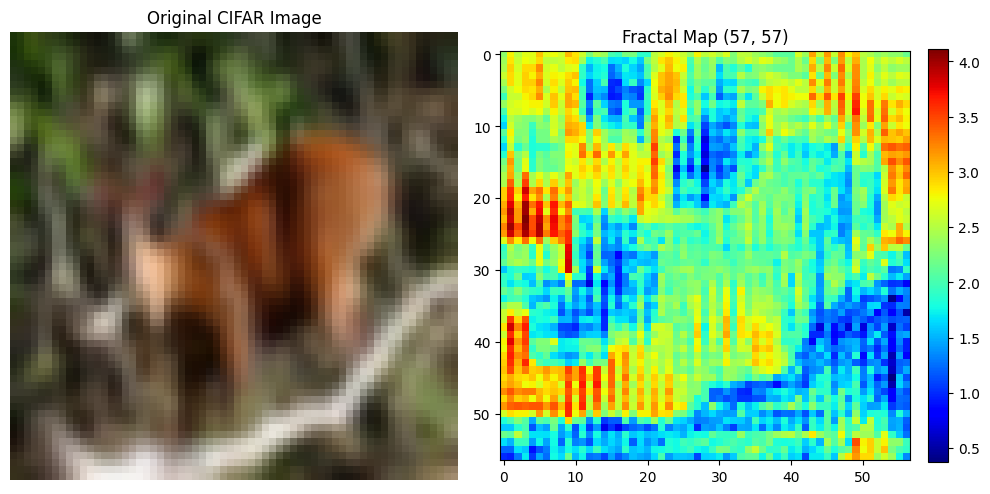

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random

# =========================
# PICK RANDOM IMAGE
# =========================
all_images = [
    os.path.join(root, f)
    for root, _, files in os.walk("/home/ubuntu/cifar2_images_resized")
    for f in files if f.endswith(".png")
]

img_path = random.choice(all_images)

# =========================
# EXTRACT CSV NAME
# =========================
parts = img_path.split(os.sep)

split = parts[-3]   # train / test
label = parts[-2]   # 0 / 1
name  = os.path.splitext(parts[-1])[0]

csv_name = f"{split}_{label}_{name}_fd.csv"
csv_path = os.path.join("fractal_maps_cifar_resized_M8_S1", csv_name)

print("Image:", img_path)
print("CSV:", csv_path)

# =========================
# CHECK + LOAD
# =========================
if not os.path.exists(csv_path):
    print("❌ CSV not found! Check naming.")
else:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fd_map = np.loadtxt(csv_path, delimiter=",")

    # =========================
    # PLOT
    # =========================
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img)
    axes[0].set_title("Original CIFAR Image")
    axes[0].axis("off")

    im = axes[1].imshow(fd_map, cmap="jet")
    axes[1].set_title(f"Fractal Map {fd_map.shape}")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()